In [37]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [43]:
dataset1 = pd.read_csv("/content/drive/MyDrive/deep learning exp/_exp 1 DL - Sheet1 (1).csv.xls")
X = dataset1[['INPUT ']].values
y = dataset1[['OUTPUT']].values

In [57]:
dataset1.head()

,INPUT,OUTPUT
0,55,65
1,79,8
2,45,53
3,65,85
4,98,25


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [45]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [47]:
# Name:
# Register Number:
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}

  def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x
        # Include your code here






In [48]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(lig.parameters(),lr=0.001)

In [49]:
# Name:
# Register Number:
def train_model(lig, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
        for epoch in range(epochs):
          optimizer.zero_grad()
          Loss=criterion(lig(X_train),y_train)
          Loss.backward()
          optimizer.step()
          lig.history['loss'].append(Loss.item())
          if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {Loss.item():.6f}')

In [50]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 4711.989746
Epoch [200/2000], Loss: 3689.895020
Epoch [400/2000], Loss: 2161.849121
Epoch [600/2000], Loss: 1007.864563
Epoch [800/2000], Loss: 719.184753
Epoch [1000/2000], Loss: 672.805237
Epoch [1200/2000], Loss: 632.525635
Epoch [1400/2000], Loss: 599.587524
Epoch [1600/2000], Loss: 575.315491
Epoch [1800/2000], Loss: 559.408081


In [51]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 1566.594849


In [54]:
loss_df = pd.DataFrame(lig.history)

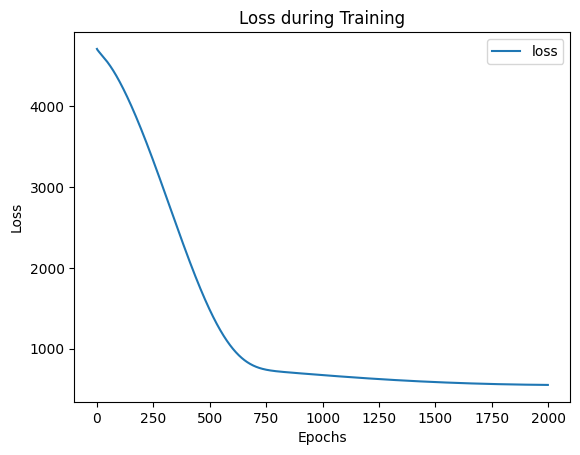

In [55]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [56]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 60.42912292480469
